<a href="https://colab.research.google.com/github/swethaukkarde/Neural-networks-and-deep-learning/blob/main/Exp_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Actual Temperatures:
 [[32.]
 [33.]
 [34.]
 [35.]
 [36.]]

Predicted Temperatures:
 [[31.804167]
 [32.89642 ]
 [33.944046]
 [35.29165 ]
 [36.167004]]


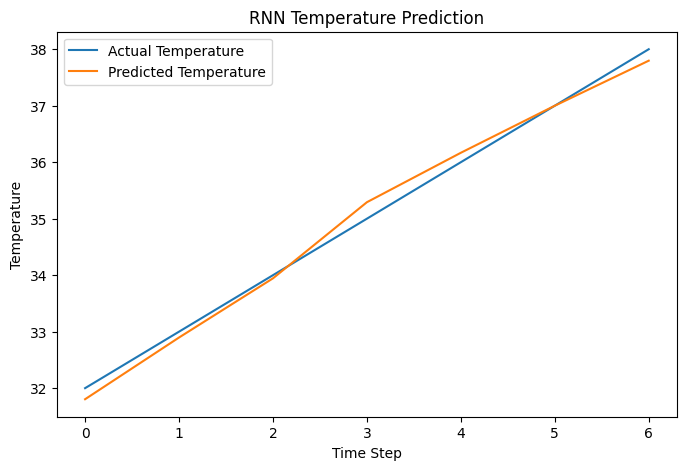

In [1]:
#exp 5

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# Step 1: Load Dataset
# -------------------------------
data = np.array([
    30, 31, 29, 32, 33, 34, 35, 36, 37, 38
], dtype=float)

# -------------------------------
# Step 2: Normalize Data
# -------------------------------
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1, 1))

# -------------------------------
# Step 3: Create Sequences
# -------------------------------
time_step = 3
X, y = [], []

for i in range(len(data_scaled) - time_step):
    X.append(data_scaled[i:i + time_step])
    y.append(data_scaled[i + time_step])

X = np.array(X)
y = np.array(y)

# -------------------------------
# Step 4: Build RNN Model
# -------------------------------
model = Sequential()

model.add(SimpleRNN(
    units=10,
    activation='tanh',
    input_shape=(time_step, 1)
))

model.add(Dense(1))

# Compile model
model.compile(
    optimizer='adam',
    loss='mse'
)

# -------------------------------
# Step 5: Train Model
# -------------------------------
history = model.fit(
    X, y,
    epochs=100,
    verbose=0
)

# -------------------------------
# Step 6: Predictions
# -------------------------------
predicted = model.predict(X)

# Convert back to original scale
predicted = scaler.inverse_transform(predicted)
actual = scaler.inverse_transform(y)

# -------------------------------
# Step 7: Print Output
# -------------------------------
print("Actual Temperatures:\n", actual[:5])
print("\nPredicted Temperatures:\n", predicted[:5])

# -------------------------------
# Step 8: Visualization
# -------------------------------
plt.figure(figsize=(8,5))

plt.plot(actual, label="Actual Temperature")
plt.plot(predicted, label="Predicted Temperature")

plt.title("RNN Temperature Prediction")
plt.xlabel("Time Step")
plt.ylabel("Temperature")
plt.legend()

plt.show()